# Orbital environment

## Initialize

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib widget

In [2]:
from math import radians, pi, sin
import matplotlib.pyplot as plt
from tqdm.auto import trange
import xarray.ufuncs as xrf
import numba as nb
import numpy as np
from numba.experimental import jitclass
from IPython.display import display, JSON

from cw.context import time_it
from cw.filters import smooth_signal

from traj1.logger import Logger

from environment import LauncherV1Orbital, Stage, AP_NONE, AP_PITCH_CONTROL, AP_FLIGHT_PATH_CONTROL, AP_PITCH_RATE_CONTROL

## Create new Environment

Creates a new environment with an attached logger.

In [3]:
moon_radius = 1737.4e3

In [4]:
env = LauncherV1Orbital({
    "theta_e_random_window": radians(30),
    "stages": (
        Stage( 
            dry_mass=1,
            propellant_mass=0.95,
            specific_impulse=400,
            thrust=4*1.7),
    ),
    # "initial_theta_e": radians(15),
    # "autopilot_mode": AP_FLIGHT_PATH_CONTROL,
    # "initial_kepler": {
    #     "a": moon_radius + 100e3,
    #     "e": .0,
    #     "true_anomaly": 0.,
    # }
})
env

In [5]:
env.reset()

array([0.       , 1.3755246, 0.99999  , 0.       , 0.       , 1.       ],
      dtype=float32)

In [6]:
logger = Logger()
logger.register_time_attribute(env.sim, "t")
logger.register(env.sim, "env", [
    "h", "i", "vie", "vie_hat", "reward",
    "gamma_e", "theta_e", "theta_i_dot",
    "ap_comm_gamma_e", "ap_comm_theta_e",
    "action_autopilot_mode", "action_autopilot_reference",
    "vii", "xii", "fii_thrust", "mass", "mass_dot",
    "end_at_apogee", "end_at_ground",
    "semi_major_axis", "eccentricity"
])

In [7]:
n_episodes = 1
max_time = 1500

last_episode_result = None
batch_results = None

logger.episode_reset()
logger.batch_reset()
with time_it("sim"):
    for episiode_idx in range(n_episodes):
        observation = env.reset()
        for i in range(int(max_time / env.sim.integrator.h)):
            pitch_angle = 0.5 * pi - 0.003 * env.sim.t
            # pitch_angle = 0
            observation, reward, done, info = env.step(pitch_angle)
            logger.step()
            if done:
                
                break
        last_episode_result = logger.episode_finish()
batch_results = logger.batch_finish()

sim: 4.07389583600002 [s]


In [8]:
last_episode_result

<xarray.Dataset>
Dimensions:                         (t: 30000, d_2_0: 2)
Coordinates:
  * t                               (t) float64 0.05 0.1 ... 1.5e+03 1.5e+03
Dimensions without coordinates: d_2_0
Data variables: (12/21)
    env_h                           (t) float64 1.0 0.9959 ... 1.089e+06
    env_i                           (t) int64 1 2 3 4 ... 29998 29999 30000
    env_vie                         (t, d_2_0) float64 7.704e-34 ... 803.1
    env_vie_hat                     (t, d_2_0) float64 9.482e-33 -1.0 ... 0.569
    env_reward                      (t) float64 -10.0 -10.0 ... -14.7 -14.7
    env_gamma_e                     (t) float64 -1.571 0.1907 ... 0.6053 0.6053
    ...                              ...
    env_mass                        (t) float64 1.95 1.95 1.95 ... 1.0 1.0 1.0
    env_mass_dot                    (t) float64 -0.001733 -0.001733 ... 0.0 0.0
    env_end_at_apogee               (t) bool False False False ... False False
    env_end_at_ground               (t) bool True True True ... True True True
    env_semi_major_axis             (t) float64 8.687e+05 ... 3.316e+06
    env_eccentricity                (t) float64 1.0 1.0 1.0 ... 0.5819 0.5819

In [12]:
result = last_episode_result

In [15]:
sum(result.env_reward.values)

-295617.17898958805

<Figure size 640x480 with 0 Axes>

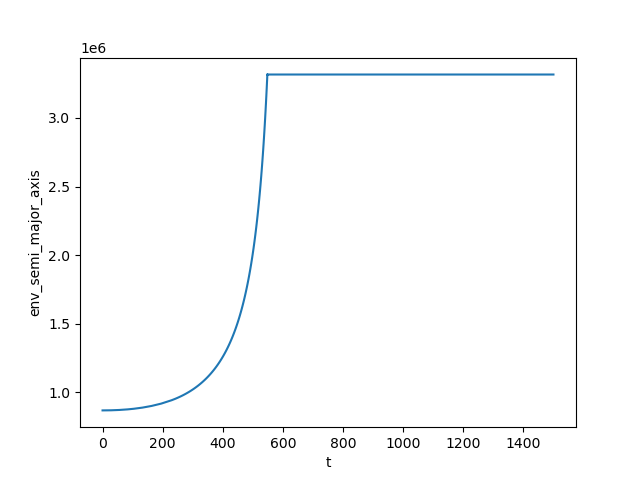

In [9]:
plt.figure()
last_episode_result.env_semi_major_axis.plot.line(x="t")
# abs(last_episode_result.env_gamma_e - 0.5 * pi).plot.line(x="t")
# last_episode_result.env_gamma_e.plot.line(x="t")
# last_episode_result.env_vie_hat.plot.line(x="t")
# last_episode_result.env_h.plot.line(x="t")

<Figure size 640x480 with 0 Axes>

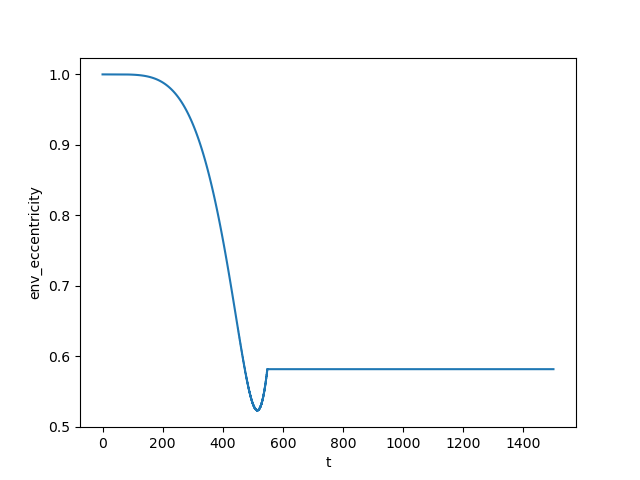

In [24]:
plt.figure()
last_episode_result.env_eccentricity.plot.line(x="t")

<Figure size 640x480 with 0 Axes>

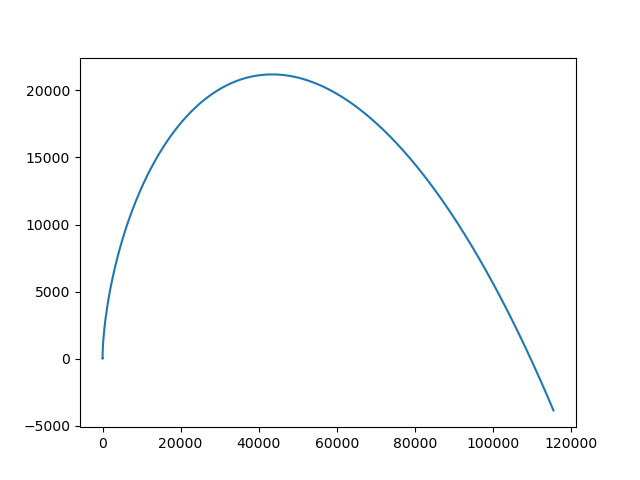

In [12]:
plt.figure()
plt.plot(last_episode_result.env_xii.values[:, 0], last_episode_result.env_xii.values[:, 1] - last_episode_result.env_xii.values[0, 1])

<Figure size 640x480 with 0 Axes>

(-1937400.0, 1937400.0)

(-1937400.0, 1937400.0)

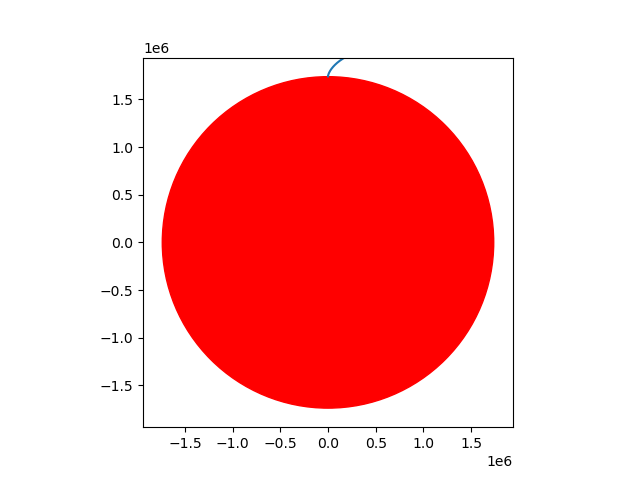

In [10]:
plt.figure()


lim_size = moon_radius + 200e3
moon = plt.Circle((0, 0), moon_radius, color='r')
ax = plt.gca()
ax.add_patch(moon)

plt.plot(last_episode_result.env_xii.values[:, 0], 
         last_episode_result.env_xii.values[:, 1])

# moon = plt.Circle((last_episode_result.env_xii.values[0, 0], last_episode_result.env_xii.values[0, 1]), moon_radius/ 10, color='b')
# ax = plt.gca()
# ax.add_patch(moon)

ax.set_aspect('equal')
plt.xlim([-lim_size, lim_size])
plt.ylim([-lim_size, lim_size])

In [12]:
env.reset()

array([0.        , 0.26179939, 0.00083333])

In [13]:
a = pi * 0.5

env.sim.step((
    True,
    False,
    nb.int32(1),
    nb.float64(pi * 0.4),
))
env.sim_states_dict()

{'t': '0.05',
 'action_engine_on': 'True',
 'action_drop_stage': 'False',
 'action_autopilot_mode': '1',
 'action_autopilot_reference': '1.2566370614359172',
 'ap_comm_gamma_e': 'nan',
 'ap_comm_theta_e': 'nan',
 'gii': '[-9.94965859e-17 -1.62490256e+00]',
 'xii': '[1.06385129e-10 1.73740100e+06]',
 'vii': '[-4.97482929e-18 -8.12451280e-02]',
 'aii': '[ 5.47357968 -0.1582613 ]',
 'tei': '[[-1.000000e+00  6.123234e-17]\n [ 6.123234e-17  1.000000e+00]]',
 'vie': '[ 7.70371978e-34 -8.12451280e-02]',
 'fii_thrust': '[6.56829562 1.75996951]',
 'theta_i': '0.2617993877991494',
 'theta_i_dot': '0.0',
 'theta_e': '0.26179938779914913',
 'mass': '1.2',
 'mass_dot': '-0.008664627930682975',
 'h': '1.0',
 'engine_on': 'True',
 'stage_state': '1',
 'stage_idx': '0',
 'stage_ignitions_left': '-2',
 'gamma_i': '-1.5707963267948968',
 'gamma_e': '-1.5707963267948968',
 'longitude': '1.5707963267948966',
 'reward': '0.0',
 'score': '0.0',
 'done': 'False'}